In [1]:
%load_ext autoreload

In [2]:
%autoreload 1

In [3]:
import os, sys
import numpy as np
from rich import print
from rich.pretty import pprint
from rich.progress import track
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
import hist
from hist import Hist
import mplhep as hep
import uproot

parent_dir = os.path.dirname(os.path.abspath(""))
sys.path.append(parent_dir)

import cms_styles

%aimport plot_utils

In [4]:
mpl.rcParams.update({"figure.max_open_warning": 0})
hep.style.use("CMS")
np.set_printoptions(suppress=True)

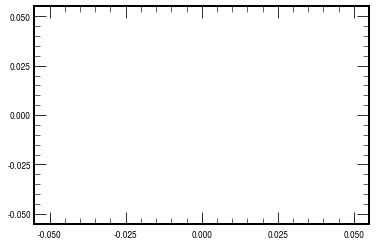

In [5]:
plt.plot()
hep.style.use(hep.style.CMS)
mpl.rcParams["figure.facecolor"] = "white"
plt.style.use(cms_styles.CMS_petroff_10)

## Do PU plots

In [24]:
file_in_mc_old = uproot.open("../../data/pileup/mcPileupUL2016.root")
file_in_mc_new = uproot.open("../../data/pileup/mc_pileup_UL16.root")

In [25]:
h_mc_new = file_in_mc_new["mc_pileup"].to_hist()
h_mc_old = file_in_mc_old["pu_mc"].to_hist()

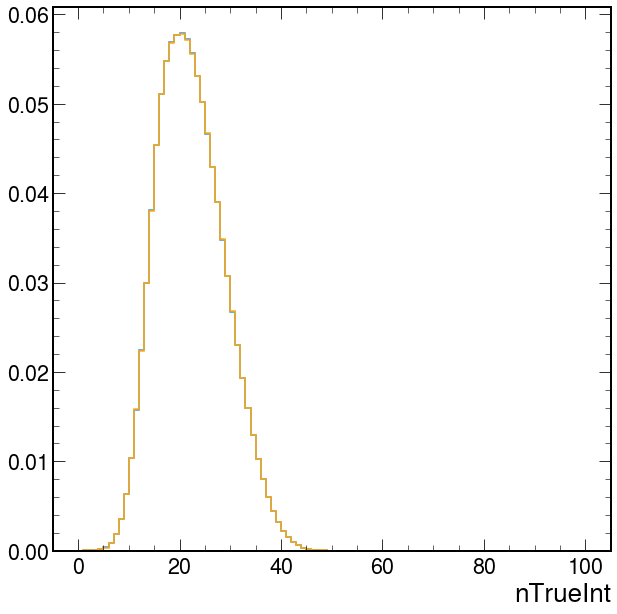

In [26]:
h_mc_new.plot(yerr=0, density=True)
h_mc_old.plot(yerr=0, density=True)
plt.show()

In [31]:
files_per_era = {
    "UL16": {
        "data": "PileupHistogram-goldenJSON-13tev-2016-withvars-99bins.root",
        "mc": "mc_pileup_UL16.root",
    },
    "UL16APV": {
        "data": "PileupHistogram-goldenJSON-13tev-2016-withvars-99bins.root",
        "mc": "mc_pileup_UL16APV.root",
    },
    "UL17": {
        "data": "PileupHistogram-goldenJSON-13tev-2017-withvars-99bins.root",
        "mc": "mc_pileup_UL17.root",
    },
    "UL18": {
        "data": "PileupHistogram-goldenJSON-13tev-2018-withvars-99bins.root",
        "mc": "mc_pileup_UL18.root",
    },
    "2022": {
        "data": "pileupHistogram-Cert_Collisions2022_355100_357900_eraBCD_GoldenJson-13p6TeV-2022-withvars-99bins.root",
        "mc": "mc_pileup_2022.root",
    },
    "2022EE": {
        "data": "pileupHistogram-Cert_Collisions2022_359022_362760_eraEFG_GoldenJson-13p6TeV-2022EE-withvars-99bins.root",
        "mc": "mc_pileup_2022EE.root",
    },
    "2023": {
        "data": "pileupHistogram-Cert_Collisions2023_366403_369802_eraBC_GoldenJson-13p6TeV-2023-withvars-99bins.root",
        "mc": "mc_pileup_2023.root",
    },
    "2023BPix": {
        "data": "pileupHistogram-Cert_Collisions2023_369803_370790_eraD_GoldenJson-13p6TeV-2023BPix-withvars-99bins.root",
        "mc": "mc_pileup_2023BPix.root",
    },
}

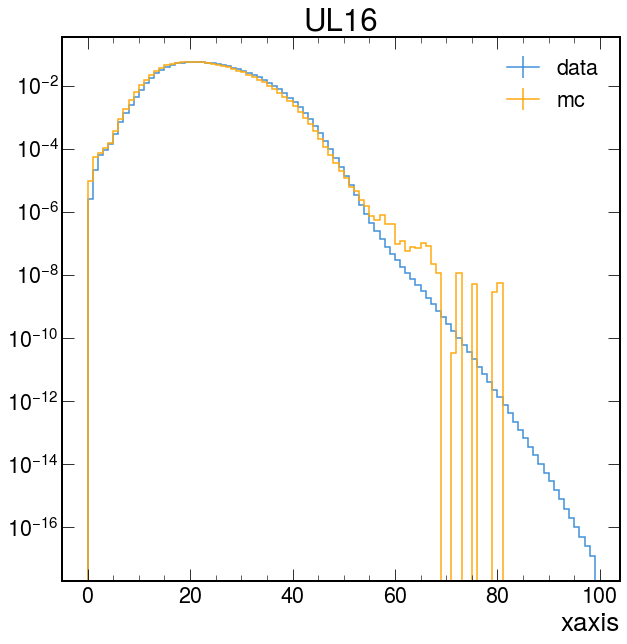

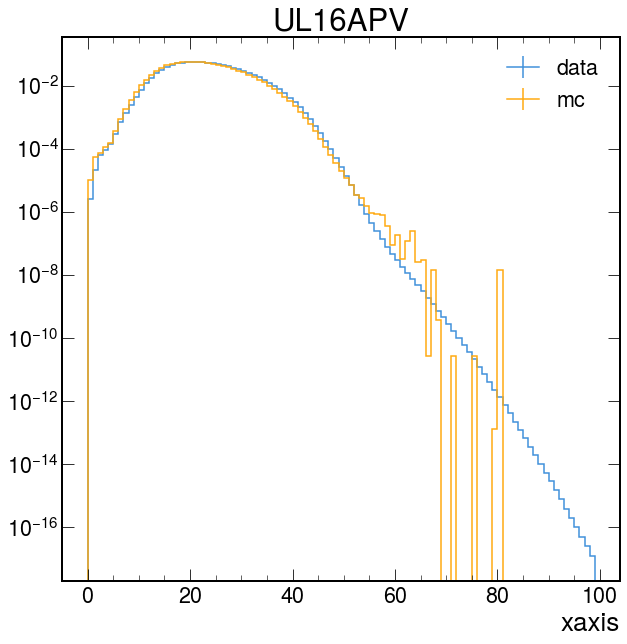

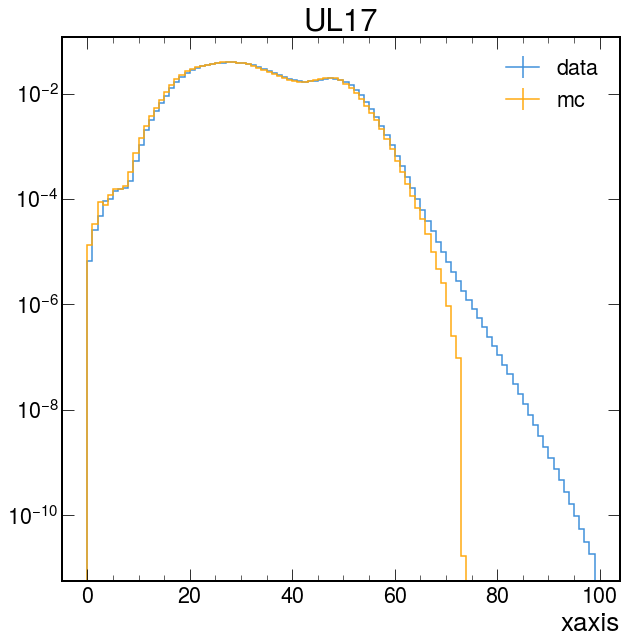

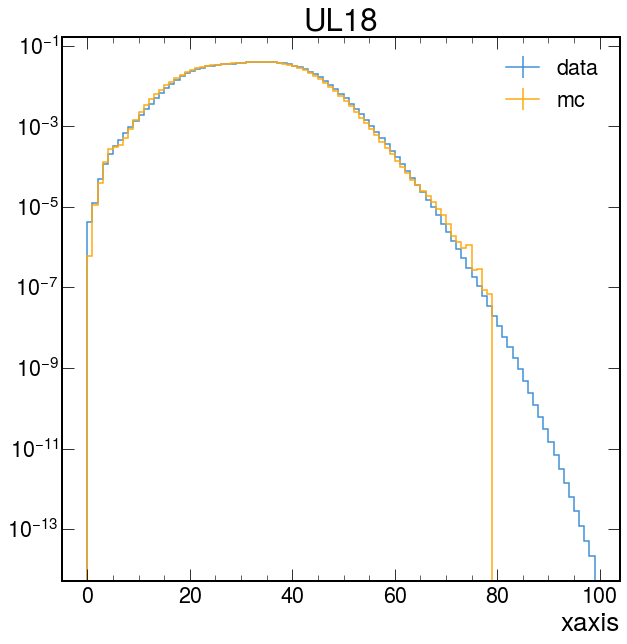

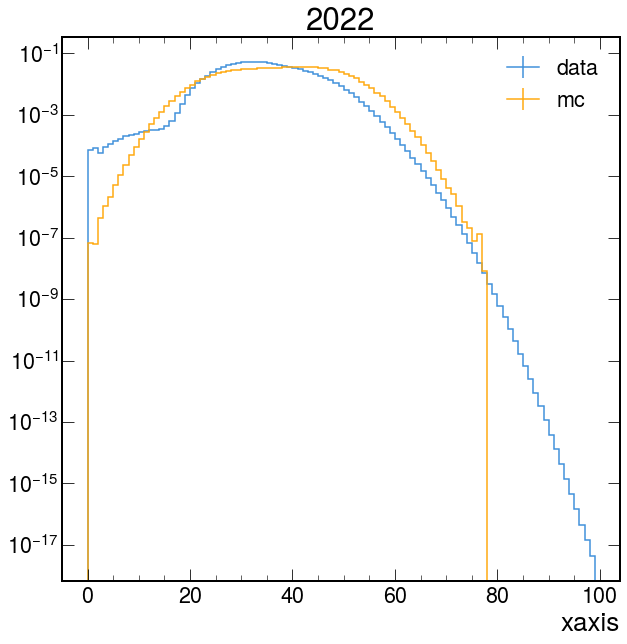

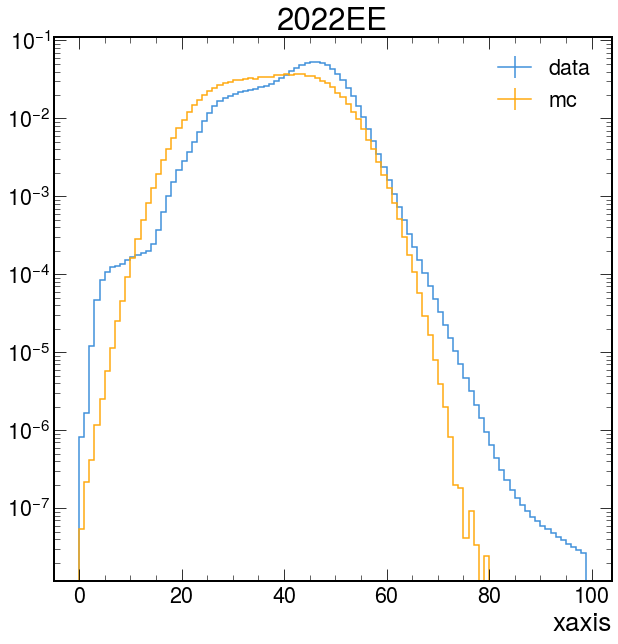

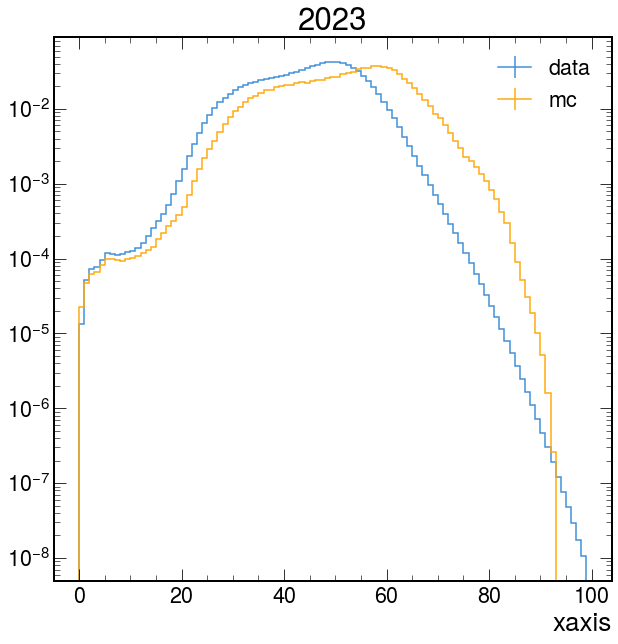

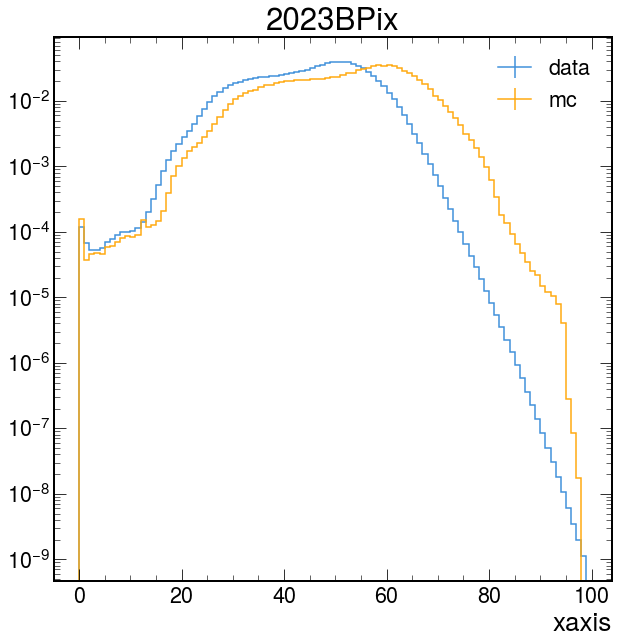

In [54]:
for era in files_per_era:
    # Data
    file_in_data = uproot.open(f"../../data/pileup/{files_per_era[era]['data']}")
    h_data = file_in_data["pileup"].to_hist()
    hep.histplot(h_data, yerr=0, density=True, label="data")
    # MC
    file_in_mc = uproot.open(f"../../data/pileup/{files_per_era[era]['mc']}")
    h_mc = file_in_mc["mc_pileup"].to_hist()
    hep.histplot(h_mc, yerr=0, density=True, label="mc")
    plt.title(era)
    plt.legend()
    plt.yscale("log")
    plt.show()

In [55]:
era = "2023BPix"
file_in_data = uproot.open(f"../../data/pileup/{files_per_era[era]['data']}")
h_data = file_in_data["pileup"].to_hist()
file_in_mc = uproot.open(f"../../data/pileup/{files_per_era[era]['mc']}")
h_mc = file_in_mc["mc_pileup"].to_hist()
h_data = h_data.to_numpy()
h_mc = h_mc.to_numpy()
normed_mc = h_mc[0] / h_mc[0].sum()
normed_data = h_data[0] / h_data[0].sum()
weights = np.divide(
    normed_data, normed_mc, out=np.ones_like(normed_data), where=normed_mc != 0
)

In [59]:
weights[np.array([34, 44, 22])]

array([1.52090394, 1.4686062 , 2.22584769])